In [41]:
import pandas as pd
import duckdb as ddb
import matplotlib.pyplot as plt

### Wattnet data

In [42]:
wattnet_data = pd.read_csv("/Users/biancachiusano/Desktop/uva/thesis/energy-aware-vm-consolidation/datasets/entsoe_wattnet/wattnet_footprints.csv")

In [43]:
wattnet_data.head(10)

,timestamp,carbon_operational_global,carbon_operational_local,carbon_life-cycle_global,carbon_life-cycle_local,water_operational_global,water_operational_local,water_life-cycle_global,water_life-cycle_local
0,2024-12-14T00:00:00Z,193.30,211.82,216.16,236.19,4.30,4.46,8.80,9.37
1,2024-12-14T00:15:00Z,183.48,201.31,205.08,224.32,4.95,5.21,9.41,10.09
2,2024-12-14T00:30:00Z,181.54,199.88,202.53,222.25,4.91,5.18,9.45,10.15
3,2024-12-14T00:45:00Z,183.77,202.62,204.84,225.10,4.46,4.66,9.07,9.73
4,2024-12-14T01:00:00Z,183.35,203.36,204.54,226.18,4.19,4.39,8.77,9.42
5,2024-12-14T01:15:00Z,185.41,203.80,206.28,226.10,4.02,4.18,8.75,9.34
6,2024-12-14T01:30:00Z,185.03,205.03,205.69,227.21,3.71,3.84,8.47,9.06
7,2024-12-14T01:45:00Z,185.24,206.09,205.87,228.32,3.56,3.67,8.33,8.93
8,2024-12-14T02:00:00Z,183.40,204.85,203.58,226.69,3.42,3.53,8.24,8.86
9,2024-12-14T02:15:00Z,181.41,202.65,201.18,224.02,3.51,3.64,8.35,8.99


In [44]:
wattnet_data["timestamp"] = pd.to_datetime(wattnet_data["timestamp"], utc=True)
wattnet_data.head()

,timestamp,carbon_operational_global,carbon_operational_local,carbon_life-cycle_global,carbon_life-cycle_local,water_operational_global,water_operational_local,water_life-cycle_global,water_life-cycle_local
0,2024-12-14 00:00:00+00:00,193.30,211.82,216.16,236.19,4.30,4.46,8.80,9.37
1,2024-12-14 00:15:00+00:00,183.48,201.31,205.08,224.32,4.95,5.21,9.41,10.09
2,2024-12-14 00:30:00+00:00,181.54,199.88,202.53,222.25,4.91,5.18,9.45,10.15
3,2024-12-14 00:45:00+00:00,183.77,202.62,204.84,225.10,4.46,4.66,9.07,9.73
4,2024-12-14 01:00:00+00:00,183.35,203.36,204.54,226.18,4.19,4.39,8.77,9.42


### Node Snapshot data

In [22]:
baseline = pd.read_parquet("/Users/biancachiusano/Desktop/uva/thesis/energy-aware-vm-consolidation/datasets/cloud_energy_consumption/processed/node_snapshot.parquet")
#baseline = baseline[["timestamp", "simulated_power"]]
baseline.head()

,timestamp,node_name,node_group,cpu_usage_percent,ipmi_system_power_watts,cpu_capacity,power_capacity,memory_capacity_mb,memory_available_mb,vm_count,vm_power_allocated,cpu_allocated,memory_allocated_mb,baseline_power,simulated_power
0,2024-12-14 00:00:00+00:00,00366801,a6177608,0.23,404.17,128,1100.0,386653.664062,366137.002604,0,0.0,0.0,0.0,404.17,404.17
1,2024-12-14 00:00:00+00:00,0049db0c,a6177608,0.21,415.00,128,1100.0,386653.667969,289728.684245,0,0.0,0.0,0.0,415.00,415.00
2,2024-12-14 00:00:00+00:00,0064a367,a6177608,99.88,784.17,128,1100.0,386653.667969,1589.156901,0,0.0,0.0,0.0,784.17,784.17
3,2024-12-14 00:00:00+00:00,0065ef1b,a6177608,0.03,410.00,128,1100.0,386653.664062,366362.100911,0,0.0,0.0,0.0,410.00,410.00
4,2024-12-14 00:00:00+00:00,05c5ef00,a6177608,18.52,465.00,128,1100.0,386653.667969,1432.229167,0,0.0,0.0,0.0,465.00,465.00


In [23]:
baseline["timestamp"] = pd.to_datetime(baseline["timestamp"], utc=True)

In [24]:
baseline.head()

,timestamp,node_name,node_group,cpu_usage_percent,ipmi_system_power_watts,cpu_capacity,power_capacity,memory_capacity_mb,memory_available_mb,vm_count,vm_power_allocated,cpu_allocated,memory_allocated_mb,baseline_power,simulated_power
0,2024-12-14 00:00:00+00:00,00366801,a6177608,0.23,404.17,128,1100.0,386653.664062,366137.002604,0,0.0,0.0,0.0,404.17,404.17
1,2024-12-14 00:00:00+00:00,0049db0c,a6177608,0.21,415.00,128,1100.0,386653.667969,289728.684245,0,0.0,0.0,0.0,415.00,415.00
2,2024-12-14 00:00:00+00:00,0064a367,a6177608,99.88,784.17,128,1100.0,386653.667969,1589.156901,0,0.0,0.0,0.0,784.17,784.17
3,2024-12-14 00:00:00+00:00,0065ef1b,a6177608,0.03,410.00,128,1100.0,386653.664062,366362.100911,0,0.0,0.0,0.0,410.00,410.00
4,2024-12-14 00:00:00+00:00,05c5ef00,a6177608,18.52,465.00,128,1100.0,386653.667969,1432.229167,0,0.0,0.0,0.0,465.00,465.00


In [25]:
baseline = baseline[["timestamp", "simulated_power"]]
baseline.head()

,timestamp,simulated_power
0,2024-12-14 00:00:00+00:00,404.17
1,2024-12-14 00:00:00+00:00,415.00
2,2024-12-14 00:00:00+00:00,784.17
3,2024-12-14 00:00:00+00:00,410.00
4,2024-12-14 00:00:00+00:00,465.00


In [26]:
baseline_agg = (
    baseline
    .groupby("timestamp", as_index=False)["simulated_power"]
    .sum()
    .rename(columns={"simulated_power": "total_simulated_power"})
)
baseline_agg.head()

,timestamp,total_simulated_power
0,2024-12-14 00:00:00+00:00,44234.11
1,2024-12-14 00:03:00+00:00,44431.64
2,2024-12-14 00:06:00+00:00,44355.31
3,2024-12-14 00:09:00+00:00,44428.48
4,2024-12-14 00:12:00+00:00,44295.16


### Merging

In [31]:
node_and_cf = cf_wattnet.merge(baseline_agg, on="timestamp", how="left")
node_and_cf

,timestamp,carbon_footprint,total_simulated_power
0,2024-12-14 00:00:00+00:00,216.16,44234.11
1,2024-12-14 00:15:00+00:00,205.08,44229.97
2,2024-12-14 00:30:00+00:00,202.53,44251.65
3,2024-12-14 00:45:00+00:00,204.84,44457.12
4,2024-12-14 01:00:00+00:00,204.54,44497.53
...,...,...,...
11611,2025-04-13 22:45:00+00:00,121.27,38032.51
11612,2025-04-13 23:00:00+00:00,122.67,38171.46
11613,2025-04-13 23:15:00+00:00,126.58,38142.33
11614,2025-04-13 23:30:00+00:00,125.27,38073.67


### Convert power to energy

In [ ]:
# converting to kwh
node_and_cf['total_simulated_power'] = node_and_cf['simulated_power'] * 0.05 / 1000


### Plot

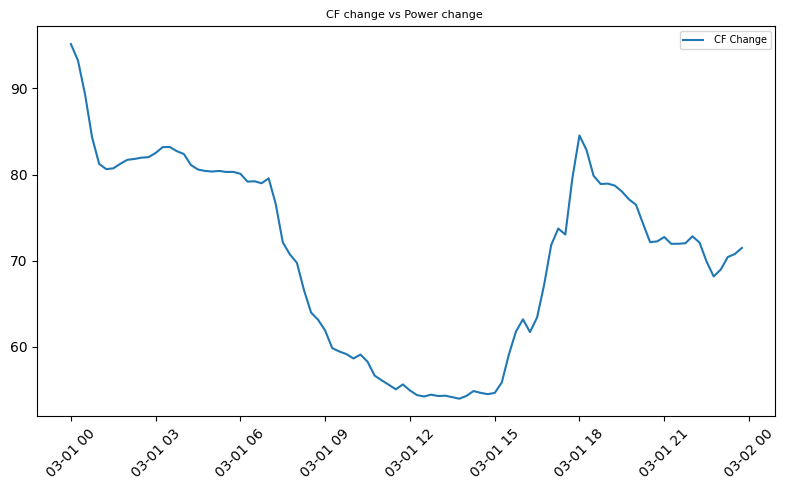

In [40]:
def plot_percentage_changes(complete_df):

    df = complete_df[
        (complete_df["timestamp"] >= "2025-03-01") &
        (complete_df["timestamp"] < "2025-03-02")
    ]
    

    fig, ax = plt.subplots(figsize=(8, 5))

    #df["cf_pct_change"] = df["carbon_footprint"].pct_change()
    df["cf_pct_change"] = df["carbon_footprint"]
    #df["power_pct_change"] = df["total_simulated_power"].pct_change()

    df["power_pct_change"] = df["total_simulated_power"]

    ax.plot(df["timestamp"], df["cf_pct_change"], label=f" CF Change")
    #ax.plot(df["timestamp"], df["power_pct_change"], label="Simulated Power")
    
    ax.set_title(f"CF change vs Power change ", fontsize=8)
    ax.tick_params(axis='x', labelrotation=45)
    ax.legend(fontsize=7)

    fig.tight_layout()
    plt.show()

plot_percentage_changes(node_and_cf)